In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
y = np.array([35, 40, 50, 60, 65, 70])


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)


In [5]:
print("Training Performance")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("R²:", r2_score(y_train, y_train_pred))

print("\nTesting Performance")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("R²:", r2_score(y_test, y_test_pred))


Training Performance
MSE: 1.875
R²: 0.9657142857142857

Testing Performance
MSE: 18.625
R²: -1.98


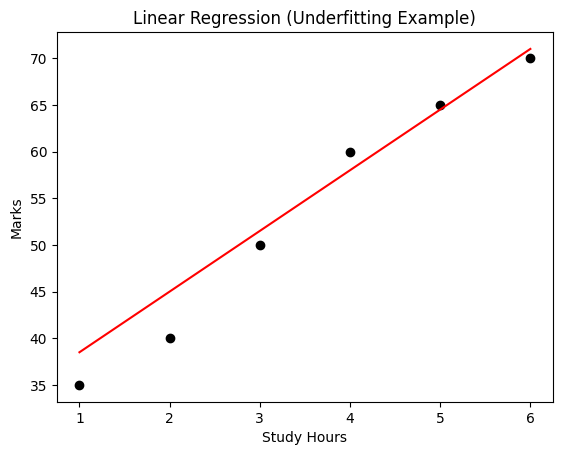

In [6]:
plt.scatter(X, y, color='black')
plt.plot(X, lin_reg.predict(X), color='red')
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression (Underfitting Example)")
plt.show()


In [7]:
print("\nGOOD FIT (Linear Regression)")
print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Test R²:", r2_score(y_test, y_test_pred))



GOOD FIT (Linear Regression)
Test MSE: 18.625
Test R²: -1.98


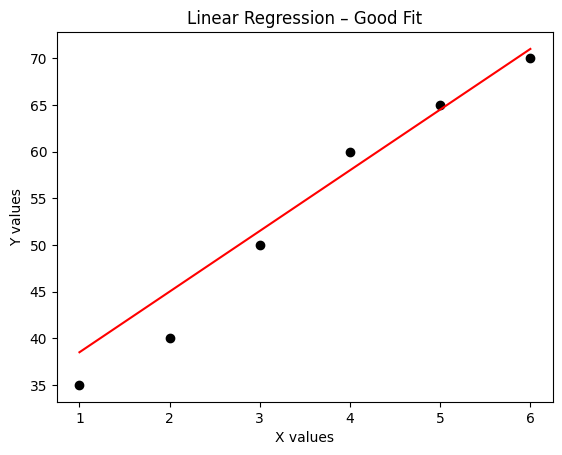

In [8]:
plt.scatter(X, y, color='black')
plt.plot(X, lin_reg.predict(X), color='red')
plt.title("Linear Regression – Good Fit")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.show()


In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
poly = PolynomialFeatures(degree=5)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

overfit_model = LinearRegression()
overfit_model.fit(X_train_poly, y_train)

y_train_pred_poly = overfit_model.predict(X_train_poly)
y_test_pred_poly = overfit_model.predict(X_test_poly)


In [10]:
print("OVERFITTING MODEL (Polynomial Regression)")

print("Train MSE:", mean_squared_error(y_train, y_train_pred_poly))
print("Train R²:", r2_score(y_train, y_train_pred_poly))

print("Test MSE:", mean_squared_error(y_test, y_test_pred_poly))
print("Test R²:", r2_score(y_test, y_test_pred_poly))


OVERFITTING MODEL (Polynomial Regression)
Train MSE: 8.23880018525583e-24
Train R²: 1.0
Test MSE: 17.882879121611595
Test R²: -1.8612606594578551


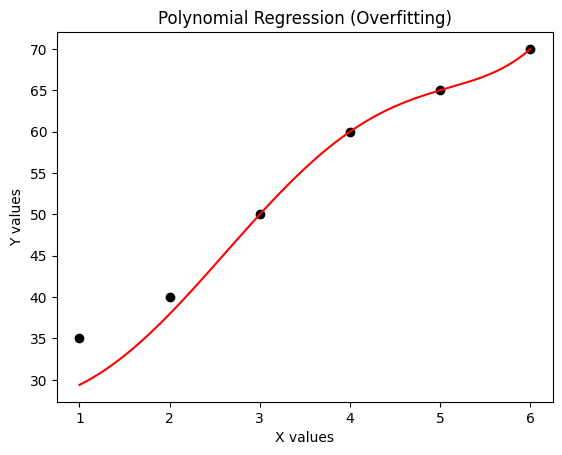

In [11]:
X_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

plt.scatter(X, y, color='black')
plt.plot(X_grid, overfit_model.predict(X_grid_poly), color='red')
plt.title("Polynomial Regression (Overfitting)")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.show()


In [13]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=5)
x_poly=poly.fit_transform(X)

In [14]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1)
ridge.fit(x_poly,y)
y_ridge_pred=ridge.predict(x_poly)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

print("Ridge Regression Performance")
print("MSE:", mean_squared_error(y, y_ridge_pred))
print("R²:", r2_score(y, y_ridge_pred))


Ridge Regression Performance
MSE: 0.24058058055628095
R²: 0.9985320506949108


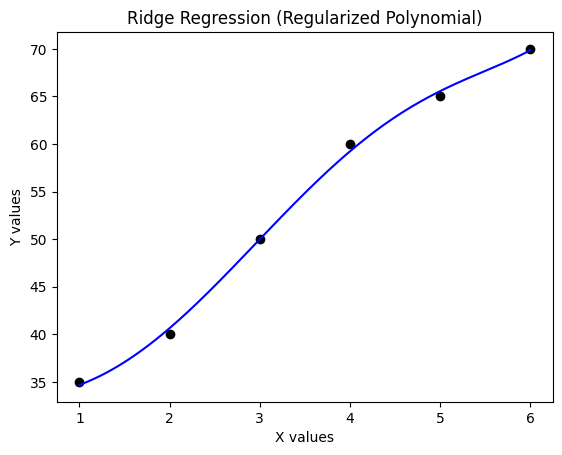

In [16]:
import matplotlib.pyplot as plt
import numpy as np

X_grid = np.linspace(1, 6, 200).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

plt.scatter(X, y, color='black')
plt.plot(X_grid, ridge.predict(X_grid_poly), color='blue')
plt.title("Ridge Regression (Regularized Polynomial)")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.show()


In [18]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(x_poly, y)

y_lasso_pred = lasso.predict(x_poly)


C:\Users\Srin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.706e+00, tolerance: 9.833e-02
  model = cd_fast.enet_coordinate_descent(


In [19]:
from sklearn.metrics import mean_squared_error, r2_score

print("Ridge MSE:", mean_squared_error(y, y_ridge_pred))
print("Ridge R²:", r2_score(y, y_ridge_pred))

print("Lasso MSE:", mean_squared_error(y, y_lasso_pred))
print("Lasso R²:", r2_score(y, y_lasso_pred))


Ridge MSE: 0.24058058055628095
Ridge R²: 0.9985320506949108
Lasso MSE: 0.4230492246347361
Lasso R²: 0.997418682697144
